# Lab 7

## Estimating max velocity

Setpoint: 0.0
Number of samples: 1500


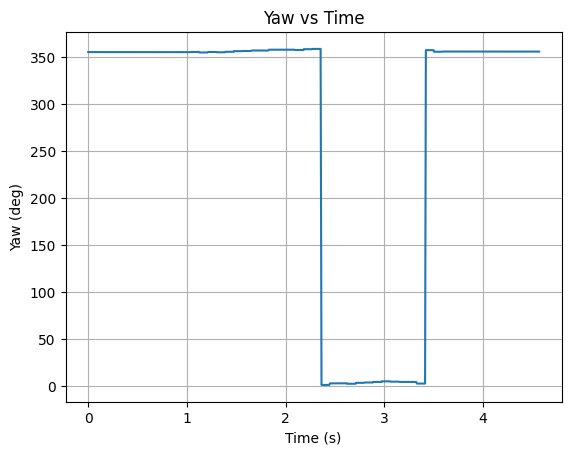

In [2]:
import threading
import time
import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime


def read_drive_data_csv(filename):
    time_ms = []
    time_s = []
    yaw_deg = []
    front_dist = []
    side_dist = []
    left_motor = []
    right_motor = []
    front_speed = []
    yaw_speed = []

    setpoint = None

    with open(filename, "r", newline="") as f:
        reader = csv.reader(f)

        # First row: setpoint,<value>
        first_row = next(reader, None)
        if first_row and len(first_row) >= 2 and first_row[0].strip().lower() == "setpoint":
            setpoint = float(first_row[1])
        else:
            raise ValueError("CSV does not start with a valid setpoint row")

        # Second row: headers
        header = next(reader, None)
        expected_header = [
            "time_ms", "time_s", "yaw_deg", "front_dist", "side_dist",
            "left_motor", "right_motor", "front_speed", "yaw_speed"
        ]

        if header is None:
            raise ValueError("CSV is missing header row")

        # Allow either full header or first 7 columns only
        if header[:len(expected_header)] != expected_header[:len(header)]:
            print("Warning: unexpected header:", header)

        # Data rows
        for row in reader:
            if not row:
                continue

            try:
                time_ms.append(int(row[0]))
                time_s.append(float(row[1]))
                yaw_deg.append(float(row[2]))
                front_dist.append(float(row[3]))
                side_dist.append(float(row[4]))
                left_motor.append(float(row[5]))
                right_motor.append(float(row[6]))

                if len(row) > 7:
                    front_speed.append(float(row[7]))
                if len(row) > 8:
                    yaw_speed.append(float(row[8]))

            except ValueError:
                print("Skipping bad row:", row)

    return {
        "setpoint": setpoint,
        "time_ms": np.array(time_ms),
        "time_s": np.array(time_s),
        "yaw_deg": np.array(yaw_deg),
        "front_dist": np.array(front_dist),
        "side_dist": np.array(side_dist),
        "left_motor": np.array(left_motor),
        "right_motor": np.array(right_motor),
        "front_speed": np.array(front_speed),
        "yaw_speed": np.array(yaw_speed),
    }

data = read_drive_data_csv("PrettyGood.csv")

print("Setpoint:", data["setpoint"])
print("Number of samples:", len(data["time_s"]))

plt.plot(data["time_s"], data["yaw_deg"])
plt.xlabel("Time (s)")
plt.ylabel("Yaw (deg)")
plt.title("Yaw vs Time")
plt.grid(True)
plt.show()